In [44]:
# Import initial libraries
import pandas as pd
import numpy as np
import boto3
from io import StringIO
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [45]:
# Load your modeling dataset from S3
# Replace the path below with your actual S3 path from Day 26
s3 = boto3.client('s3')
bucket_name = 'cmse492-lesurek1-nyc311-339713112540-us-east-1-an' # replace with your bucket name (make sure you have the account regional suffix)
file_name = 'modeling_data.csv' # make sure to include the path if it's in a folder, e.g. 'modeling/modeling_data.csv'

obj = s3.get_object(Bucket=bucket_name, Key=file_name)
data = obj['Body'].read().decode('utf-8')
df = pd.read_csv(StringIO(data))

print(f"Shape: {df.shape}")
df.head()

Shape: (173851, 8)


,agency,borough,problem,incident_zip,day_of_week,hour_of_day,same_day_complaint_volume,days_to_close
0,DCWP,QUEENS,Consumer Complaint,11418.0,6,13,17,1
1,DCWP,BROOKLYN,Consumer Complaint,11220.0,6,9,17,3
2,DCWP,QUEENS,Consumer Complaint,11432.0,6,11,17,1
3,DCWP,BROOKLYN,Consumer Complaint,11203.0,6,22,17,45
4,DCWP,QUEENS,Consumer Complaint,11373.0,6,12,17,1


In [46]:
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Columns: ['agency', 'borough', 'problem', 'incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume', 'days_to_close']

Missing values:
agency                          0
borough                         0
problem                         0
incident_zip                 1765
day_of_week                     0
hour_of_day                     0
same_day_complaint_volume       0
days_to_close                   0
dtype: int64

Data types:
agency                        object
borough                       object
problem                       object
incident_zip                 float64
day_of_week                    int64
hour_of_day                    int64
same_day_complaint_volume      int64
days_to_close                  int64
dtype: object


In [47]:
# Define feature columns and target column
# Replace these with your actual column names
feature_cols = ['agency', 'borough', 'incident_zip', 'problem', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume', 'days_to_close']  # <-- update this
target_col   = 'problem'          # <-- update this

# If your target needs to be binarized or modified in some way, do it here
# Example: df['high_volume'] = (df['volume_quartile'] == 1).astype(int)

X = df[feature_cols]
y = df[target_col]

print(f"Features: {feature_cols}")
print(f"Target: {target_col}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True).round(3).to_dict()}")

Features: ['agency', 'borough', 'incident_zip', 'problem', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume', 'days_to_close']
Target: problem

Target distribution:
problem
Illegal Parking                         28835
HEAT/HOT WATER                          28232
Noise - Residential                     16623
Snow or Ice                             11846
Blocked Driveway                        11033
                                        ...  
DEP Street Condition                        1
Lifeguard                                   1
Radioactive Material                        1
Special Natural Area District (SNAD)        1
Public Toilet                               1
Name: count, Length: 147, dtype: int64

Class balance: {'Illegal Parking': 0.166, 'HEAT/HOT WATER': 0.162, 'Noise - Residential': 0.096, 'Snow or Ice': 0.068, 'Blocked Driveway': 0.063, 'Street Condition': 0.037, 'Traffic Signal Condition': 0.031, 'Noise - Street/Sidewalk': 0.021, 'Water System': 0.021, 'Dirty C

In [49]:
# Import train_test_split for splitting the data
from sklearn.model_selection import train_test_split

# Train/test split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3))

Training set:  139080 rows
Test set:      34771 rows

Class balance in training set:
problem
Illegal Parking                 0.166
HEAT/HOT WATER                  0.162
Noise - Residential             0.095
Snow or Ice                     0.068
Blocked Driveway                0.064
                                ...  
DEP Street Condition            0.000
Public Toilet                   0.000
Pet Sale                        0.000
Building Drinking Water Tank    0.000
Highway Sign - Dangling         0.000
Name: proportion, Length: 142, dtype: float64

Class balance in test set:
problem
Illegal Parking          0.167
HEAT/HOT WATER           0.163
Noise - Residential      0.097
Snow or Ice              0.069
Blocked Driveway         0.063
                         ...  
Uprooted Stump           0.000
Wayfinding               0.000
Drinking Water           0.000
Posting Advertisement    0.000
Pet Sale                 0.000
Name: proportion, Length: 132, dtype: float64


In [50]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Identify categorical vs. numeric columns automatically
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns     ({len(num_cols)}): {num_cols}")

# Build the transformer:
#   - OneHotEncoder for categorical columns
#     drop='first'         avoids multicollinearity (k-1 dummies per feature)
#     sparse_output=False  returns a regular numpy array (easier to inspect)
#     handle_unknown='ignore'  silently zeros out categories not seen in training
#   - StandardScaler for numeric columns (optional but often helpful for models like Logistic Regression)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols),  # scale numeric columns
    ]
)

# Fit ONLY on training data, then apply to both splits
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)
X_train_enc = np.nan_to_num(X_train_enc)
X_test_enc = np.nan_to_num(X_test_enc)
# Recover feature names for later coefficient inspection
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
encoded_feature_names = ohe_names + num_cols

print(f"\nEncoded feature matrix shape: {X_train_enc.shape}")
print(f"Total features after encoding: {len(encoded_feature_names)}")
print(f"\nFirst few encoded feature names: {encoded_feature_names[:10]}")

Categorical columns (3): ['agency', 'borough', 'problem']
Numeric columns     (5): ['incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume', 'days_to_close']


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



Encoded feature matrix shape: (139080, 163)
Total features after encoding: 163

First few encoded feature names: ['agency_DEP', 'agency_DHS', 'agency_DOB', 'agency_DOE', 'agency_DOHMH', 'agency_DOT', 'agency_DPR', 'agency_DSNY', 'agency_HPD', 'agency_NYPD']


In [51]:
from sklearn.linear_model import LogisticRegression

# Train the logistic regression baseline (adjust the model type and parameters as needed for your specific task)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_enc, y_train)

print("Model trained successfully.")
print(f"Classes: {model.classes_}")

Model trained successfully.
Classes: ['AHV Inspection Unit' 'APPLIANCE' 'Abandoned Bike' 'Abandoned Vehicle'
 'Air Quality' 'Animal Facility - No Permit' 'Animal in a Park'
 'Animal-Abuse' 'Asbestos' 'BEST/Site Safety' 'Beach/Pool/Sauna Complaint'
 'Bike Rack' 'Bike/Roller/Skate' 'Blocked Driveway' 'Boilers'
 'Bridge Condition' 'Broken Parking Meter' 'Building Drinking Water Tank'
 'Building/Use' 'Bus Stop Shelter Complaint' 'Bus Stop Shelter Placement'
 'Cannabis Retailer' 'Commercial Disposal Complaint' 'Consumer Complaint'
 'Curb Condition' 'DEP Street Condition' 'DOOR/WINDOW' 'Damaged Tree'
 'Day Care' 'Dead Animal' 'Dead/Dying Tree' 'Dept of Investigations'
 'Derelict Vehicles' 'Dirty Condition' 'Disorderly Youth' 'Drinking'
 'Drinking Water' 'Drug Activity' 'Dumpster Complaint' 'E-Scooter'
 'ELECTRIC' 'ELEVATOR' 'Electrical' 'Elevator'
 'Emergency Response Team (ERT)' 'Encampment' 'FLOORING/STAIRS'
 'Food Establishment' 'Food Poisoning' 'For Hire Vehicle Complaint'
 'For Hire Veh

In [52]:
# Inspect the model coefficients
# After encoding, use encoded_feature_names instead of feature_cols
coef_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Model coefficients (top 10 by magnitude):")
print(coef_df.head(10).to_string(index=False))
print("\nPositive coefficient = feature pushes toward the positive class")
print("Negative coefficient = feature pushes toward the negative class")

Model coefficients (top 10 by magnitude):
                               feature  coefficient
                           day_of_week     0.684416
                            agency_DOB     0.443207
                     borough_MANHATTAN     0.303013
                         days_to_close     0.274094
                           hour_of_day     0.169529
             same_day_complaint_volume     0.045393
problem_Institution Disposal Complaint    -0.000007
       problem_For Hire Vehicle Report    -0.000007
          problem_DEP Street Condition    -0.000046
                      problem_Pet Sale    -0.000074

Positive coefficient = feature pushes toward the positive class
Negative coefficient = feature pushes toward the negative class


In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Generate predictions on the test set
y_pred = model.predict(X_test_enc)

# Compute metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")

Accuracy:  0.999
Precision: 0.999
Recall:    0.999


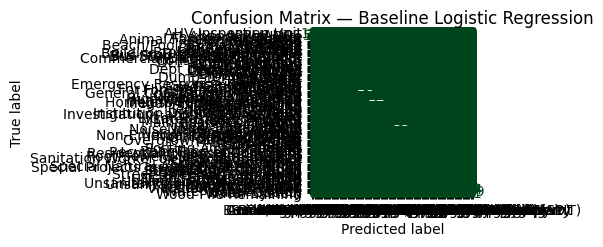

Confusion matrix saved to confusion_matrix.png


In [55]:
# Plot the confusion matrix
labels = model.classes_

cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — Baseline Logistic Regression') 
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()
print("Confusion matrix saved to confusion_matrix.png")